# Wind + grid electrolyser LCA

Pulls hourly wind power from Renewables.ninja, aligns to half-hour grid rows,
then runs the electrolyser LCA per slice in either **blended** or **switching**
supply mode.

All settings live in [dashboard_config.py](dashboard_config.py).
Toggle with `RUN_WIND_GRID_LCA`; choose `WIND_LCA_MODE`.
Pick the LCA engine with `WIND_METHOD_MODE = "exact"` or `"cheap"` (cheap
decomposes each tech once and combines scores linearly — much faster).

The output CSV is consumed by the dashboard notebook for plotting.


In [10]:
# All settings come from dashboard_config.py — the single master dashboard.
# Edit values there once; every notebook picks them up.
from dashboard_config import *
import dashboard_config as cfg
import lca_helpers as H

print_dashboard()
print()
ei, bio, fg_db, method = H.setup_brightway()

Master Dashboard
----------------
Project:                 hydrogen-smr
Foreground DB:           hydrogen foreground
Build foreground DB:     True
Run reference LCA:       False
Run grid scenario LCA:   True
Run wind/grid LCA:       True
Grid method:             exact | loss factor: 1.0316426921769999
Selected grid techs:     ['AE operation']
Wind/grid mode:          both (blended + switching) | electrolyser(s): ['AE operation']

Current Brightway project: hydrogen-smr
Using ecoinvent database: ecoinvent-3.9.1-apos
Using biosphere database: ecoinvent-3.9.1-biosphere
Using foreground database: hydrogen foreground
Using LCIA method: ('ecoinvent-3.9.1', 'IPCC 2021 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')


In [11]:
if not RUN_WIND_GRID_LCA:
    raise SystemExit(
        "RUN_WIND_GRID_LCA is False in dashboard_config.py. Set it True and re-run."
    )

if fg_db is None:
    raise SystemExit(
        "Foreground database not found. Run tech_lca_foreground.ipynb first."
    )

print("Wind/grid run")
print("-------------")
print("LCA mode:                  ", WIND_LCA_MODE)
print("Grid time mode:            ", GRID_TIME_MODE)
if GRID_TIME_MODE == "single":
    print("Window:                    ", GRID_SINGLE_DATETIME)
else:
    print("Window:                    ", GRID_RANGE_START, "->", GRID_RANGE_END)
print("Electrolyser capacity (kW):", ELECTROLYSER_CAPACITY_KW)
print("Wind installed cap. (kW):  ", WIND_INSTALLED_CAPACITY_KW)
print("Electrolyser tech(s):      ", ELECTROLYSER_TECHS)

Wind/grid run
-------------
LCA mode:                   both
Grid time mode:             year_average
Window:                     2023-01-15 00:00:00 -> 2023-01-16 00:00:00
Electrolyser capacity (kW): 1000.0
Wind installed cap. (kW):   1000.0
Electrolyser tech(s):       ['AE operation']


## Load CSV and pick the 48 half-hour rows

In [12]:
import pandas as pd

selected_grid_source = getattr(cfg, "GRID_SOURCE_NORMALIZED", cfg.normalise_grid_data_source(getattr(cfg, "GRID_DATA_SOURCE", "csv")))

if selected_grid_source == "csv":
    # Use the old CSV selector, matching 4.custom_grid.ipynb.
    grid_df = H.load_grid_csv()
    run_rows, target_label = H.select_grid_rows(grid_df)
else:
    # For 4.1, reuse the exact API-derived rows selected by the grid notebook.
    # This requires running via 2.dashboard_lca_adaptive.ipynb, or running 4.1 first
    # in the same kernel before this notebook.
    if "DASHBOARD_GRID_RUN_ROWS" not in globals():
        raise RuntimeError(
            "GRID_DATA_SOURCE='carbon_api' requires the API-derived grid rows from "
            "4.1.custom_grid_carbon_intensity_api.ipynb. Run 2.dashboard_lca_adaptive.ipynb "
            "with RUN_GRID_NOTEBOOK_FROM_DASHBOARD=True, or run 4.1 first in this kernel."
        )
    run_rows = DASHBOARD_GRID_RUN_ROWS.copy()
    target_label = DASHBOARD_GRID_TARGET_LABEL

run_rows["DATETIME"] = pd.to_datetime(run_rows["DATETIME"]).dt.tz_localize(None)

print(f"Selected rows: {len(run_rows)}  ({target_label})")
print("Grid data source:", selected_grid_source)
print("Start:", run_rows["DATETIME"].min())
print("End  :", run_rows["DATETIME"].max())
_preview_cols = [c for c in ["DATETIME", "GENERATION", "CARBON_INTENSITY", "WIND", "WIND_perc", "api_scope", "api_region_id"] if c in run_rows.columns]
run_rows[_preview_cols].head()


Loaded 305,447 rows from df_fuel_ckan.csv
Date range: 2009-01-01 00:00:00 → 2026-06-04 11:00:00
Selected rows: 576  (year2023_representative_576days)
Start: 2023-02-07 00:00:00
End  : 2023-12-23 23:30:00


,DATETIME,GENERATION,CARBON_INTENSITY,WIND,WIND_perc
0,2023-02-15 00:00:00,27159.0,133.0,8468.0,31.2
1,2023-02-15 00:30:00,27857.0,137.0,8601.0,30.9
2,2023-02-15 01:00:00,28245.0,136.0,8510.0,30.1
3,2023-02-15 01:30:00,28096.0,133.0,8729.0,31.1
4,2023-02-15 02:00:00,27500.0,133.0,8821.0,32.1


## Renewables.ninja session + wind data fetch

In [13]:
date_from = run_rows["DATETIME"].min().date().isoformat()
date_to   = run_rows["DATETIME"].max().date().isoformat()

def _fetch_with_session(session):
    return H.fetch_ninja_wind(
        session=session,
        lat=WIND_LAT, lon=WIND_LON,
        date_from=date_from, date_to=date_to,
        capacity_kw=WIND_INSTALLED_CAPACITY_KW,
        height_m=NINJA_HUB_HEIGHT_M,
        turbine=NINJA_TURBINE,
        dataset=NINJA_DATASET,
    )

# Try current token (env/prompt), then allow up to 2 explicit re-entry retries.
max_attempts = 3
last_exc = None
for attempt in range(1, max_attempts + 1):
    if attempt == 1:
        ninja_session = H.create_ninja_session()
    else:
        from getpass import getpass
        prompt_fn = getpass if USE_GETPASS else input
        retry_token = prompt_fn(
            f"Re-enter Renewables.ninja API token (attempt {attempt}/{max_attempts}, blank to abort): "
        ).strip()
        if not retry_token:
            raise RuntimeError("Wind data fetch aborted: no retry token provided.") from last_exc
        ninja_session = H.create_ninja_session(token=retry_token)

    try:
        wind_hourly_df, ninja_metadata, ninja_args = _fetch_with_session(ninja_session)
        break
    except RuntimeError as exc:
        last_exc = exc
        msg = str(exc).lower()
        if "authentication failed" not in msg and "status 401" not in msg and "status 403" not in msg:
            raise
        print("\nRenewables.ninja auth failed.")
        print("Check token validity and account quota, then retry.")
else:
    raise RuntimeError(
        "Wind data fetch failed after multiple token attempts. "
        "Set a valid RENEWABLES_NINJA_TOKEN and rerun this cell."
    ) from last_exc

if wind_hourly_df is None or wind_hourly_df.empty:
    raise RuntimeError("Renewables.ninja returned no wind data for the selected dates.")

wind_hourly_df.head()

Renewables.ninja session created. Source: dashboard_config; token length: 40
Status: 200
URL: https://www.renewables.ninja/api/data/wind?lat=51.732&lon=-0.3711&date_from=2023-02-07&date_to=2023-12-23&dataset=merra2&capacity=1000.0&height=80&turbine=Vestas+V90+2000&format=json


,wind_power_kw,wind_power_mw,wind_capacity_factor
time,,,
2023-02-07 00:00:00,9.347,0.009347,0.009347
2023-02-07 01:00:00,11.367,0.011367,0.011367
2023-02-07 02:00:00,13.950,0.013950,0.013950
2023-02-07 03:00:00,15.302,0.015302,0.015302
2023-02-07 04:00:00,15.917,0.015917,0.015917


## Align wind power onto half-hour slices

In [14]:
aligned_rows = H.align_wind_to_grid_timeslices(
    wind_hourly_df, run_rows, method=WIND_TO_HALFHOUR_METHOD,
)

_preview_mode = "switching" if WIND_LCA_MODE == "switching" else "blended"
if _preview_mode == "blended":
    print("Mean wind fraction:", aligned_rows["wind_fraction"].mean())
    print("Mean grid fraction:", aligned_rows["grid_fraction"].mean())
    cols = ["DATETIME", "wind_power_kw", "electrolyser_power_kw",
            "wind_fraction", "grid_fraction", "wind_used_kw",
            "grid_topup_kw", "surplus_wind_kw", "CARBON_INTENSITY"]
else:
    print("Slices per source:")
    print(aligned_rows["electricity_source"].value_counts())
    cols = ["DATETIME", "wind_power_kw", "minimum_required_wind_kw",
            "wind_above_minimum", "electricity_source", "CARBON_INTENSITY"]
aligned_rows[cols].head(12)

Mean wind fraction: 0.3666345729166667
Mean grid fraction: 0.6333654270833333


,DATETIME,wind_power_kw,electrolyser_power_kw,wind_fraction,grid_fraction,wind_used_kw,grid_topup_kw,surplus_wind_kw,CARBON_INTENSITY
0,2023-02-15 00:00:00,274.402,1000.0,0.274402,0.725598,274.402,725.598,0.0,133.0
1,2023-02-15 00:30:00,274.402,1000.0,0.274402,0.725598,274.402,725.598,0.0,137.0
2,2023-02-15 01:00:00,234.552,1000.0,0.234552,0.765448,234.552,765.448,0.0,136.0
3,2023-02-15 01:30:00,234.552,1000.0,0.234552,0.765448,234.552,765.448,0.0,133.0
4,2023-02-15 02:00:00,213.128,1000.0,0.213128,0.786872,213.128,786.872,0.0,133.0
5,2023-02-15 02:30:00,213.128,1000.0,0.213128,0.786872,213.128,786.872,0.0,138.0
6,2023-02-15 03:00:00,220.093,1000.0,0.220093,0.779907,220.093,779.907,0.0,143.0
7,2023-02-15 03:30:00,220.093,1000.0,0.220093,0.779907,220.093,779.907,0.0,140.0
8,2023-02-15 04:00:00,237.417,1000.0,0.237417,0.762583,237.417,762.583,0.0,144.0
9,2023-02-15 04:30:00,237.417,1000.0,0.237417,0.762583,237.417,762.583,0.0,143.0


## Plot the wind/grid supply for the selected mode

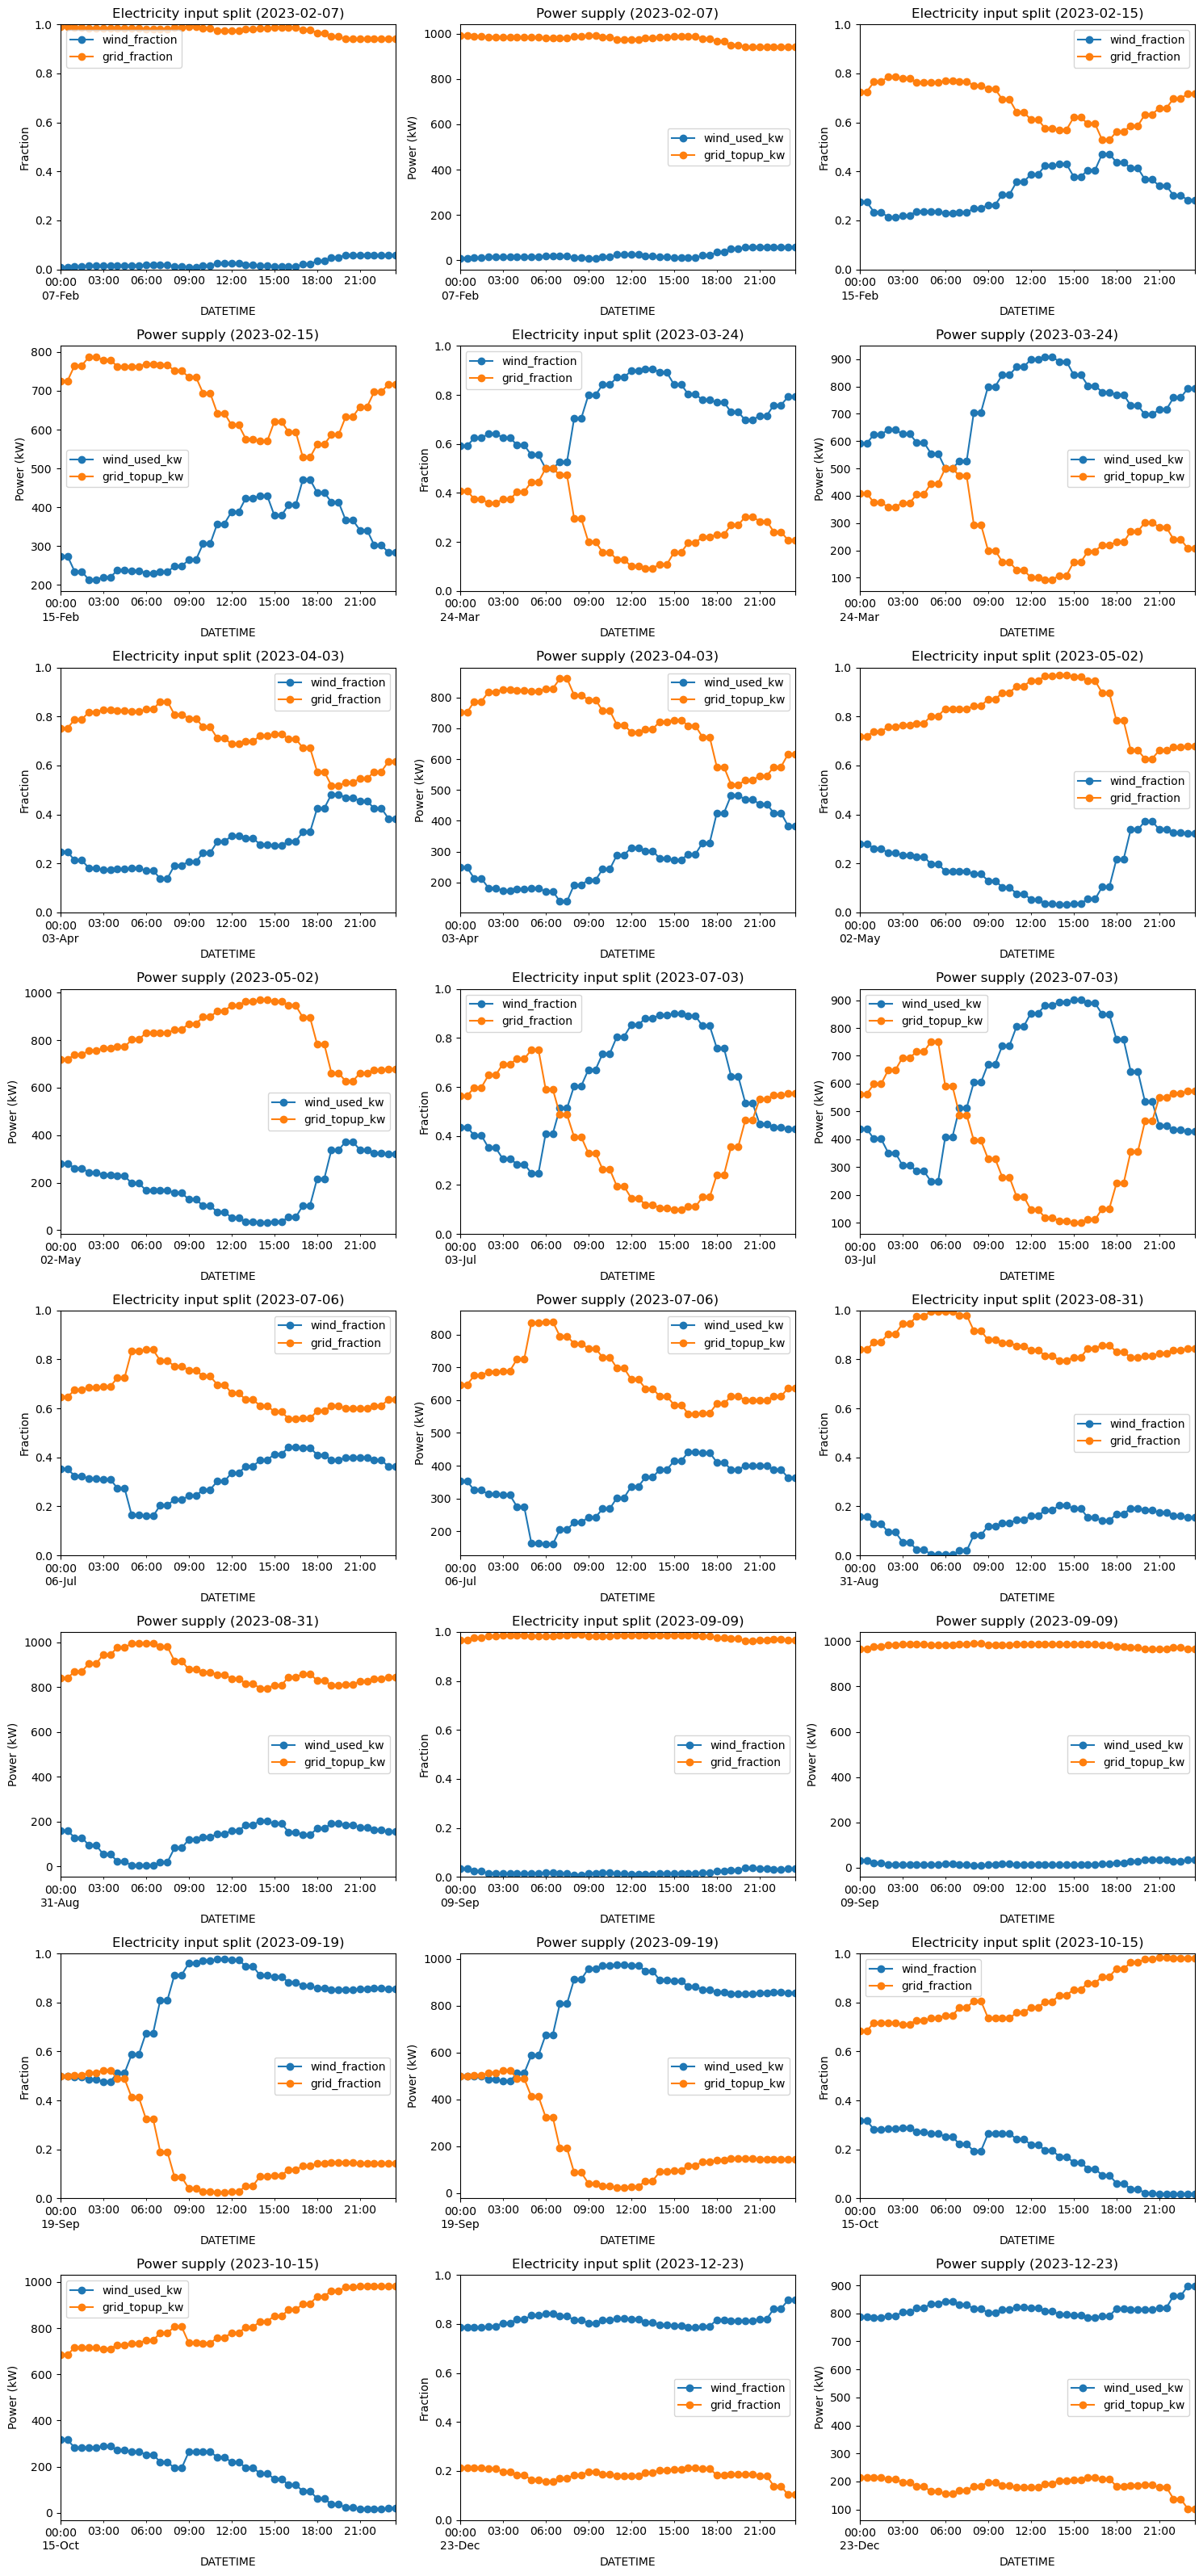

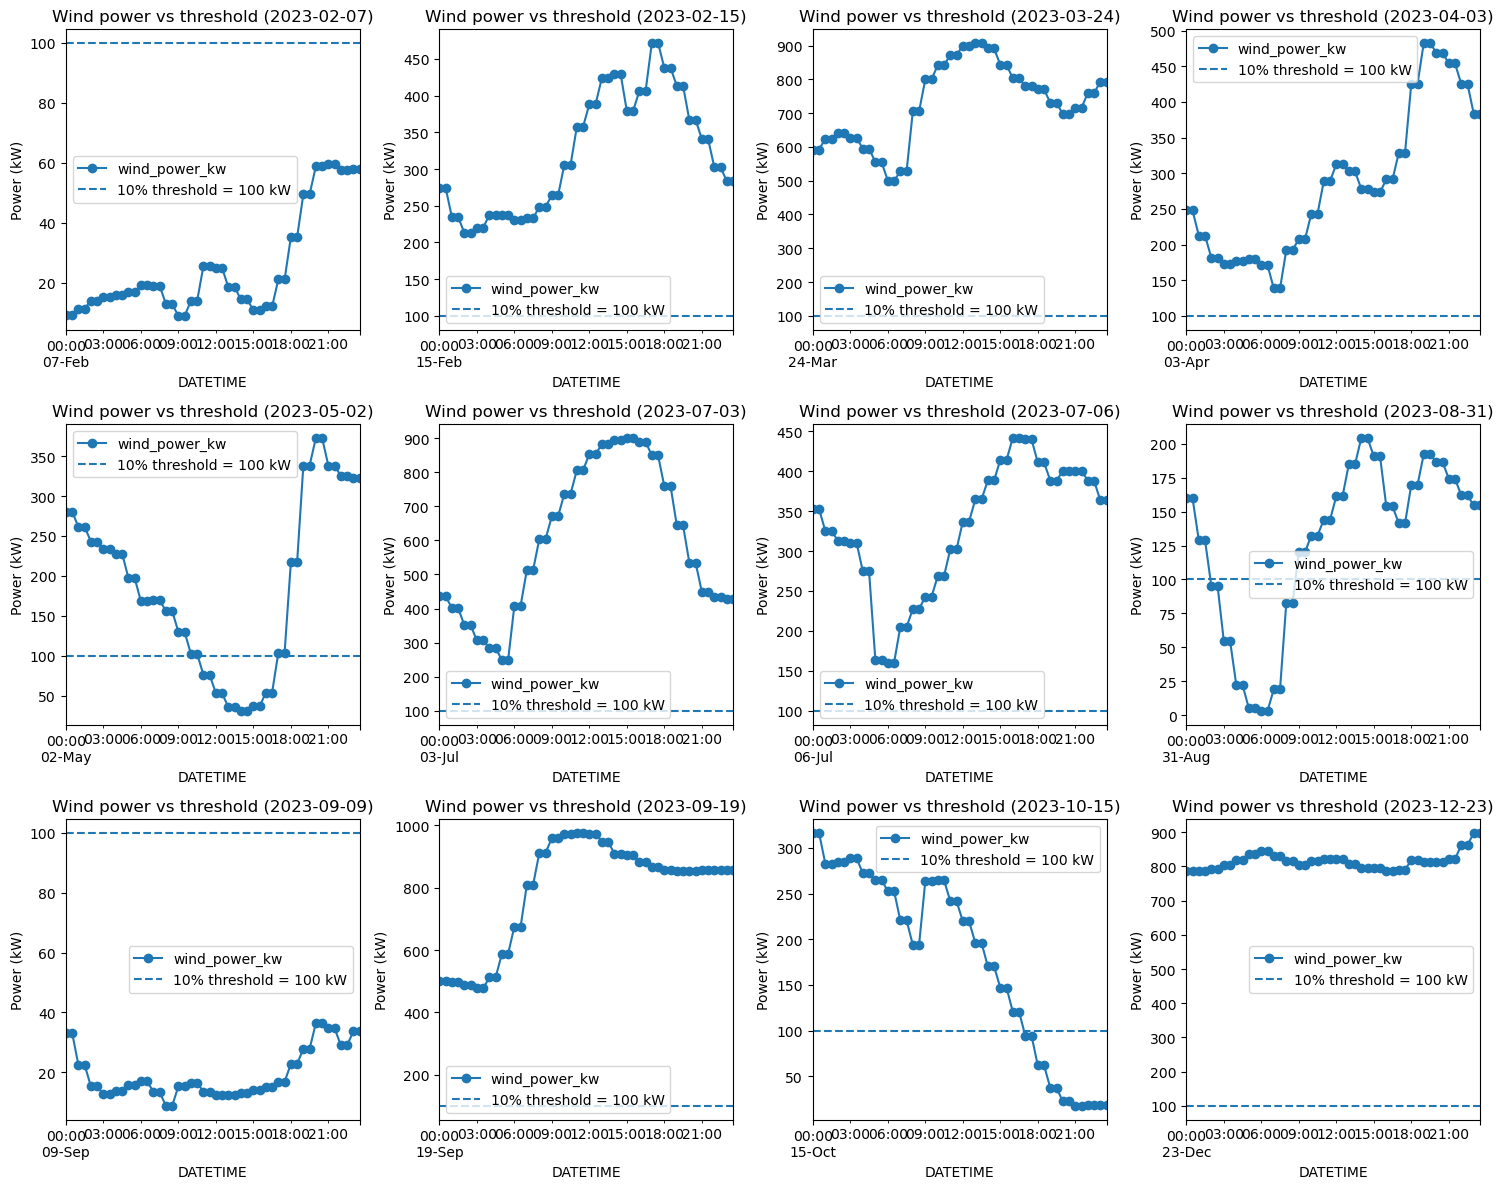

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Safety cap for the per-day grid (used by single / year_average modes) so a
# figure never exceeds matplotlib's 65536-pixel limit.
MAX_PREVIEW_DAYS = 8


def _hourly_band(df, col):
    """Aggregate a column across all days by time-of-day.

    Returns a frame indexed by hour-of-day (0..24) with the 7 stats used for
    the 24-hour "box-and-whisker as lines" view: min, 5th percentile, Q1,
    median (Q2), Q3, 95th percentile and max. Min and max are the true
    extremes for each time-of-day slot; the rest are aggregates.
    """
    g = df.copy()
    g["tod"] = g["DATETIME"].dt.hour + g["DATETIME"].dt.minute / 60.0
    return g.groupby("tod")[col].agg(
        bottom="min",
        p05=lambda s: s.quantile(0.05),
        q1=lambda s: s.quantile(0.25),
        median="median",
        q3=lambda s: s.quantile(0.75),
        p95=lambda s: s.quantile(0.95),
        top="max",
    ).sort_index()


def _plot_hourly_band(ax, stats, title, ylabel):
    """Plot the 7 statistic lines (min, p5, Q1, median, Q3, p95, max)."""
    ax.fill_between(stats.index, stats["q1"], stats["q3"],
                    color="#bdc3c7", alpha=0.3, label="Interquartile range")
    ax.plot(stats.index, stats["top"], color="#c0392b", lw=1.5, label="Max")
    ax.plot(stats.index, stats["p95"], color="#e74c3c", lw=1.2, ls="--", label="95th percentile")
    ax.plot(stats.index, stats["q3"], color="#e67e22", lw=1.5, label="Q3 (75%)")
    ax.plot(stats.index, stats["median"], color="#2c3e50", lw=2.5, label="Median (Q2)")
    ax.plot(stats.index, stats["q1"], color="#2980b9", lw=1.5, label="Q1 (25%)")
    ax.plot(stats.index, stats["p05"], color="#5dade2", lw=1.2, ls="--", label="5th percentile")
    ax.plot(stats.index, stats["bottom"], color="#16a085", lw=1.5, label="Min")
    ax.set_title(title)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 3))
    ax.legend(fontsize=8)


_plot_modes = ["blended", "switching"] if WIND_LCA_MODE == "both" else [WIND_LCA_MODE]

for _pm in _plot_modes:
    aligned_rows["date"] = aligned_rows["DATETIME"].dt.date
    n_days_total = aligned_rows["date"].nunique()

    if GRID_TIME_MODE == "range":
        # Range mode: collapse all days onto a single 24-hour axis and show the
        # distribution as 7 lines (min, 5th pct, Q1, median, Q3, 95th pct, max).
        # Constant figure size, no matter how many days.
        if _pm == "blended":
            fig, axes = plt.subplots(2, 2, figsize=(15, 8))
            _plot_hourly_band(axes[0, 0], _hourly_band(aligned_rows, "wind_fraction"),
                              "Wind fraction by hour", "Fraction")
            axes[0, 0].set_ylim(0, 1)
            _plot_hourly_band(axes[0, 1], _hourly_band(aligned_rows, "grid_fraction"),
                              "Grid fraction by hour", "Fraction")
            axes[0, 1].set_ylim(0, 1)
            _plot_hourly_band(axes[1, 0], _hourly_band(aligned_rows, "wind_used_kw"),
                              "Wind used by hour", "Power (kW)")
            _plot_hourly_band(axes[1, 1], _hourly_band(aligned_rows, "grid_topup_kw"),
                              "Grid top-up by hour", "Power (kW)")
            fig.suptitle(f"Blended mode — 24-hour distribution across {n_days_total} days",
                         fontsize=13, fontweight="bold")
        else:  # switching mode
            fig, ax = plt.subplots(1, 1, figsize=(12, 6))
            _plot_hourly_band(ax, _hourly_band(aligned_rows, "wind_power_kw"),
                              f"Wind power by hour — distribution across {n_days_total} days",
                              "Power (kW)")
            ax.axhline(MIN_WIND_POWER_KW, linestyle="--", color="black",
                       label=f"{MIN_LOAD_FRACTION:.0%} threshold = {MIN_WIND_POWER_KW:g} kW")
            ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()
        continue

    # single / year_average modes: keep the original per-day grid view.
    dates = sorted(aligned_rows["date"].unique())
    if n_days_total > MAX_PREVIEW_DAYS:
        print(f"[{_pm}] {n_days_total} days; showing first {MAX_PREVIEW_DAYS} for preview.")
        dates = dates[:MAX_PREVIEW_DAYS]
    n_days = len(dates)

    if _pm == "blended":
        # Create 2 plots per day (wind fraction + grid topup)
        n_plots_per_day = 2
        n_cols = 3  # 3 columns layout
        n_rows = (n_days * n_plots_per_day + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = np.atleast_1d(axes).flatten()  # Flatten to 1D for easier iteration

        ax_idx = 0
        for date in dates:
            day_data = aligned_rows[aligned_rows["date"] == date].set_index("DATETIME")

            # Plot 1: Wind and grid fractions
            day_data[["wind_fraction", "grid_fraction"]].plot(ax=axes[ax_idx], marker="o")
            axes[ax_idx].set_title(f"Electricity input split ({date})")
            axes[ax_idx].set_ylabel("Fraction")
            axes[ax_idx].set_ylim(0, 1)
            ax_idx += 1

            # Plot 2: Wind used vs grid top-up
            day_data[["wind_used_kw", "grid_topup_kw"]].plot(ax=axes[ax_idx], marker="o")
            axes[ax_idx].set_title(f"Power supply ({date})")
            axes[ax_idx].set_ylabel("Power (kW)")
            ax_idx += 1

        # Hide unused subplots
        for idx in range(ax_idx, len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()

    else:  # switching mode
        n_cols = 4  # 4 columns layout
        n_rows = (n_days + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = np.atleast_1d(axes).flatten()

        for ax_idx, date in enumerate(dates):
            day_data = aligned_rows[aligned_rows["date"] == date].set_index("DATETIME")

            day_data["wind_power_kw"].plot(ax=axes[ax_idx], marker="o")
            axes[ax_idx].axhline(MIN_WIND_POWER_KW, linestyle="--",
                                 label=f"{MIN_LOAD_FRACTION:.0%} threshold = {MIN_WIND_POWER_KW:g} kW")
            axes[ax_idx].set_title(f"Wind power vs threshold ({date})")
            axes[ax_idx].set_ylabel("Power (kW)")
            axes[ax_idx].legend()

        # Hide unused subplots
        for idx in range(len(dates), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()

## Pick the wind electricity background process & build foreground process

In [16]:
wind_candidates = H.show_candidates(WIND_BACKGROUND_QUERY, max_results=20)
if not wind_candidates:
    raise ValueError("No wind electricity candidates found. Check WIND_BACKGROUND_QUERY.")

wind_background_act = wind_candidates[WIND_BACKGROUND_INDEX]
print("\nSelected wind background process:")
print(wind_background_act)

wind_electricity_act = H.build_wind_electricity_activity(wind_background_act, fg_db)
print("\nCreated foreground wind electricity process:")
print(wind_electricity_act)

    0 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB
    1 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: NP
    2 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: RoW
    3 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: CA-QC
    4 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: CO
    5 | name: electricity production, wind, 1-3MW turbine, offshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB
    6 | name: electricity production, wind, >3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB


    7 | name: electricity production, wind, <1MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB
    8 | name: electricity production, wind, 1-3MW turbine, offshore | ref: electricity, high voltage | unit: kilowatt hour | loc: RoW
    9 | name: electricity production, wind, >3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: RoW
   10 | name: electricity production, wind, 1-3MW turbine, offshore | ref: electricity, high voltage | unit: kilowatt hour | loc: EE
   11 | name: electricity production, wind, 1-3MW turbine, offshore | ref: electricity, high voltage | unit: kilowatt hour | loc: PL
   12 | name: electricity production, wind, >3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: CA-QC
   13 | name: electricity production, wind, <1MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: RoW
   14 | name: electricity production, wind, <1MW turbine, onshore | re

## Resolve electrolyser activities

In [ ]:
# Resolve each electrolyser label to an activity: an explicit
# TECH_SOURCE_OVERRIDES entry (e.g. an AI-LCA-written foreground process)
# takes priority, else the built-in ELECTROLYSER_CODES lookup in FOREGROUND_DB.
_tech_overrides = getattr(cfg, "TECH_SOURCE_OVERRIDES", {})
electrolyser_acts = {
    tech: H.resolve_tech_activity(tech, _tech_overrides, FOREGROUND_DB)
    for tech in ELECTROLYSER_TECHS
}
print("Method:", method)
print("Electrolyser tech(s):", ELECTROLYSER_TECHS)
for tech, act in electrolyser_acts.items():
    print(f"  {tech}:", act)

print(f"\nDirect electricity exchanges that will be swapped ({WIND_LCA_MODE} mode):")
for tech, act in electrolyser_acts.items():
    print(f"-- {tech} --")
    H.preview_electricity_replacements(act)

## Run the wind/grid LCA for all selected slices

In [ ]:
import numpy as np
import pandas as pd

# Grid template dicts are defined in 4.custom_grid.ipynb.
# When running via the dashboard, custom_grid runs first and sets them in
# the kernel namespace. When running this notebook directly, run
# 4.custom_grid.ipynb first, or paste the dicts here manually.
for _req in ("GRID_CANDIDATE_INDEX", "GRID_INFRASTRUCTURE", "GRID_EMISSIONS"):
    if _req not in globals():
        raise NameError(
            f"{_req} is not defined. Run 4.custom_grid.ipynb first "
            "(or run the dashboard with RUN_GRID_NOTEBOOK=True)."
        )
_cand_idx  = GRID_CANDIDATE_INDEX
_infra     = GRID_INFRASTRUCTURE
_emissions = GRID_EMISSIONS

_method_mode = WIND_METHOD_MODE  # "exact" or "cheap"

# Progress printing throttle: printing one line per slice is the main bottleneck
# in cheap mode (tens of thousands of lines flushed to the notebook frontend).
# Print only ~20 evenly spaced progress lines per mode (plus the first/last and
# any failures). Set to 1 to restore a line for every slice.
_n_slices = len(aligned_rows)
_PROGRESS_EVERY = max(1, _n_slices // 20)
_w = len(str(_n_slices))

# --- Cheap-method precompute -------------------------------------------------
# Decompose each tech once (fixed non-electricity score + direct kWh) and run
# one-off LCAs for the wind + grid electricity per kWh. Every slice then becomes
# a cheap linear combination instead of a full per-slice Brightway LCA.
wind_elec_score = None
grid_source_scores = {}
tech_decomposition = {}
if _method_mode == "cheap":
    print("Cheap method: pre-computing one-off LCA scores...")
    wind_elec_score = H.run_lca_score(wind_electricity_act, method)
    print(f"  wind electricity score: {wind_elec_score:.6f} kg CO2e/kWh\n")
    _gen = H.select_all_candidate_activities(_cand_idx)
    grid_source_scores = H.calculate_source_lca_scores(_gen, method)
    tech_decomposition = H.decompose_technology_scores(electrolyser_acts, method, fg_db)

_effective_modes = ["blended", "switching"] if WIND_LCA_MODE == "both" else [WIND_LCA_MODE]
_all_records = []

for _eff_mode in _effective_modes:
    records = []
    wind_score_cache = {tech: None for tech in ELECTROLYSER_TECHS}
    wind_subst_count = {tech: None for tech in ELECTROLYSER_TECHS}

    print(f"\n--- Running {_eff_mode} {_method_mode.upper()} LCA for {_n_slices} slices across "
          f"{len(ELECTROLYSER_TECHS)} tech(s): {ELECTROLYSER_TECHS}...")
    if _eff_mode == "blended":
        print("Rule: electrolyser always 100%; wind fraction = min(wind/electrolyser, 1).")
    else:
        print(f"Switching rule: wind if wind_power_kw >= {MIN_WIND_POWER_KW} kW, else grid.")
    print()

    for i, (_, csv_row) in enumerate(aligned_rows.iterrows(), start=1):
        ts = csv_row["DATETIME"]
        tmp_grid_act = None
        _verbose_this = (i == 1) or (i == _n_slices) or (i % _PROGRESS_EVERY == 0)

        needs_grid = _eff_mode == "blended" or csv_row.get("electricity_source") == "grid"

        # Cheap mode: closed-form grid electricity score for this slice (per kWh).
        grid_elec_score = None
        if _method_mode == "cheap" and needs_grid:
            grid_elec_score, _ = H.custom_electricity_score_for_row(csv_row, grid_source_scores)

        # Exact mode: build a temporary per-slice custom grid activity.
        if _method_mode == "exact" and needs_grid:
            try:
                sel = H.select_candidate_activities(csv_row, _cand_idx)
                tmp_grid_act = H.build_custom_grid_electricity_activity(
                    csv_row, sel, fg_db,
                    infrastructure=_infra, emissions=_emissions, verbose=False,
                )
            except Exception as exc:
                print(f"[{i:>{_w}}/{_n_slices}] {ts} | FAILED grid build: "
                      f"{type(exc).__name__}: {exc}")
                for tech in ELECTROLYSER_TECHS:
                    records.append({
                        "datetime": ts, "lca_mode": _eff_mode,
                        "electrolyser_tech": tech, "scenario": f"{tech} ({_eff_mode})",
                        "wind_power_kw": csv_row.get("wind_power_kw", np.nan),
                        "grid_carbon_intensity_gco2_per_kwh": csv_row.get("CARBON_INTENSITY", np.nan),
                        "electricity_source": csv_row.get("electricity_source", _eff_mode),
                        "gwp100_kgco2e_per_kg_h2": np.nan,
                        "error": f"{type(exc).__name__}: {exc}",
                    })
                continue

        try:
            for tech in ELECTROLYSER_TECHS:
                elect_act = electrolyser_acts[tech]
                record = {
                    "datetime": ts, "lca_mode": _eff_mode,
                    "electrolyser_tech": tech, "scenario": f"{tech} ({_eff_mode})",
                    "wind_power_kw": csv_row.get("wind_power_kw", np.nan),
                    "grid_carbon_intensity_gco2_per_kwh": csv_row.get("CARBON_INTENSITY", np.nan),
                }
                try:
                    if _eff_mode == "blended":
                        wf = float(csv_row["wind_fraction"]); gf = float(csv_row["grid_fraction"])
                        if _method_mode == "cheap":
                            parts = tech_decomposition[tech]
                            blended_elec_score = wf * wind_elec_score + gf * grid_elec_score
                            total_dir = parts["electricity_kwh"]
                            score = parts["non_electricity_score"] + total_dir * blended_elec_score
                            n_swap = parts["n_elec_substitutions"]
                        else:
                            score, n_swap, total_dir = H.run_lca_with_split_electricity(
                                activity=elect_act, wind_elec_act=wind_electricity_act,
                                grid_elec_act=tmp_grid_act,
                                wind_fraction=wf, grid_fraction=gf,
                                method_=method, temp_suffix=f"{tech}_{_eff_mode}_{ts}", fg_database=fg_db,
                            )
                        record.update({
                            "electricity_source": "blended",
                            "wind_fraction": wf, "grid_fraction": gf,
                            "wind_used_kw": csv_row.get("wind_used_kw", np.nan),
                            "grid_topup_kw": csv_row.get("grid_topup_kw", np.nan),
                            "surplus_wind_kw": csv_row.get("surplus_wind_kw", np.nan),
                            "wind_above_minimum": np.nan,
                            "gwp100_kgco2e_per_kg_h2": score,
                            "electricity_exchanges_swapped": n_swap,
                            "direct_electricity_kwh_per_kg_h2": total_dir,
                            "wind_electricity_kwh_per_kg_h2": total_dir * wf,
                            "grid_electricity_kwh_per_kg_h2": total_dir * gf,
                            "temporary_grid_activity_code": tmp_grid_act.get("code") if tmp_grid_act else None,
                        })
                        _detail = (f"wind={csv_row['wind_power_kw']:.1f} kW | "
                                   f"wf={wf:.3f} | gf={gf:.3f}")
                    else:
                        source = csv_row["electricity_source"]
                        if _method_mode == "cheap":
                            parts = tech_decomposition[tech]
                            elec_score = wind_elec_score if source == "wind" else grid_elec_score
                            total_dir = parts["electricity_kwh"]
                            score = parts["non_electricity_score"] + total_dir * elec_score
                            n_swap = parts["n_elec_substitutions"]
                            grid_code = None
                        elif source == "wind":
                            if wind_score_cache[tech] is None:
                                score, n_swap = H.run_lca_with_replacement_electricity(
                                    elect_act, wind_electricity_act, method,
                                    temp_suffix=f"{tech}_wind", fg_database=fg_db)
                                wind_score_cache[tech] = score
                                wind_subst_count[tech] = n_swap
                            score = wind_score_cache[tech]
                            n_swap = wind_subst_count[tech]
                            grid_code = None
                        else:
                            score, n_swap = H.run_lca_with_replacement_electricity(
                                elect_act, tmp_grid_act, method,
                                temp_suffix=f"{tech}_{_eff_mode}_{ts}", fg_database=fg_db)
                            grid_code = tmp_grid_act.get("code") if tmp_grid_act else None

                        record.update({
                            "electricity_source": source,
                            "wind_fraction": 1.0 if source == "wind" else 0.0,
                            "grid_fraction": 0.0 if source == "wind" else 1.0,
                            "wind_used_kw": np.nan, "grid_topup_kw": np.nan,
                            "surplus_wind_kw": np.nan,
                            "wind_above_minimum": bool(csv_row.get("wind_above_minimum", False)),
                            "minimum_required_wind_kw": MIN_WIND_POWER_KW,
                            "gwp100_kgco2e_per_kg_h2": score,
                            "electricity_exchanges_swapped": n_swap,
                            "direct_electricity_kwh_per_kg_h2": np.nan,
                            "wind_electricity_kwh_per_kg_h2": np.nan,
                            "grid_electricity_kwh_per_kg_h2": np.nan,
                            "temporary_grid_activity_code": grid_code,
                        })
                        _detail = f"wind={csv_row['wind_power_kw']:.1f} kW | source={source}"

                    records.append(record)
                    if _verbose_this:
                        print(f"[{i:>{_w}}/{_n_slices}] {ts} | {tech:<15} | {_detail} "
                              f"→ GWP100={score:.4f} kg CO2e/kg H2")
                except Exception as exc:
                    print(f"[{i:>{_w}}/{_n_slices}] {ts} | {tech:<15} | "
                          f"FAILED: {type(exc).__name__}: {exc}")
                    record.update({
                        "electricity_source": csv_row.get("electricity_source", _eff_mode),
                        "gwp100_kgco2e_per_kg_h2": np.nan,
                        "error": f"{type(exc).__name__}: {exc}",
                    })
                    records.append(record)
        finally:
            if tmp_grid_act is not None:
                try: tmp_grid_act.delete()
                except Exception: pass

    _all_records.extend(records)

lca_df = (pd.DataFrame(_all_records)
            .sort_values(["lca_mode", "datetime", "electrolyser_tech"])
            .reset_index(drop=True))
print("\nCompleted.")
lca_df.head()

NameError: GRID_CANDIDATE_INDEX is not defined. Run 4.custom_grid.ipynb first (or run the dashboard with RUN_GRID_NOTEBOOK=True).

## Summary

In [ ]:
import numpy as np
import pandas as pd

def _col(df, name):
    """Return df[name] if present, else an empty float Series (mean/min/max -> NaN)."""
    if name in df.columns:
        return df[name]
    return pd.Series(dtype="float64")

summaries = []
for (_mode, tech), tech_df in lca_df.groupby(["lca_mode", "electrolyser_tech"], sort=False):
    n_ok = int(_col(tech_df, "gwp100_kgco2e_per_kg_h2").notna().sum())
    n_fail = len(tech_df) - n_ok
    if _mode == "blended":
        summaries.append({
            "lca_mode": _mode, "electrolyser_tech": tech,
            "slices_total": len(tech_df), "slices_ok": n_ok, "slices_failed": n_fail,
            "mean_wind_fraction": _col(tech_df, "wind_fraction").mean(),
            "mean_grid_fraction": _col(tech_df, "grid_fraction").mean(),
            "min_wind_fraction":  _col(tech_df, "wind_fraction").min(),
            "max_wind_fraction":  _col(tech_df, "wind_fraction").max(),
            "mean_gwp100_kgco2e_per_kg_h2": _col(tech_df, "gwp100_kgco2e_per_kg_h2").mean(),
            "min_gwp100_kgco2e_per_kg_h2":  _col(tech_df, "gwp100_kgco2e_per_kg_h2").min(),
            "max_gwp100_kgco2e_per_kg_h2":  _col(tech_df, "gwp100_kgco2e_per_kg_h2").max(),
            "mean_direct_electricity_kwh_per_kg_h2": _col(tech_df, "direct_electricity_kwh_per_kg_h2").mean(),
            "mean_wind_electricity_kwh_per_kg_h2":  _col(tech_df, "wind_electricity_kwh_per_kg_h2").mean(),
            "mean_grid_electricity_kwh_per_kg_h2":  _col(tech_df, "grid_electricity_kwh_per_kg_h2").mean(),
        })
    else:
        esrc = _col(tech_df, "electricity_source")
        summaries.append({
            "lca_mode": _mode, "electrolyser_tech": tech,
            "slices_total": len(tech_df), "slices_ok": n_ok, "slices_failed": n_fail,
            "slices_wind": int((esrc == "wind").sum()),
            "slices_grid": int((esrc == "grid").sum()),
            "mean_gwp100_kgco2e_per_kg_h2": _col(tech_df, "gwp100_kgco2e_per_kg_h2").mean(),
            "min_gwp100_kgco2e_per_kg_h2":  _col(tech_df, "gwp100_kgco2e_per_kg_h2").min(),
            "max_gwp100_kgco2e_per_kg_h2":  _col(tech_df, "gwp100_kgco2e_per_kg_h2").max(),
            "wind_share_of_slices": (esrc == "wind").mean() if len(esrc) else np.nan,
            "grid_share_of_slices": (esrc == "grid").mean() if len(esrc) else np.nan,
        })

summary_df = pd.DataFrame(summaries).set_index(["lca_mode", "electrolyser_tech"])
if "error" in lca_df.columns and lca_df["error"].notna().any():
    print("⚠ Some slices failed. First error:")
    print("  ", lca_df.loc[lca_df["error"].notna(), "error"].iloc[0])
summary_df

## Export results CSV (consumed by the dashboard notebook)

In [ ]:
from pathlib import Path

_effective_modes = ["blended", "switching"] if WIND_LCA_MODE == "both" else [WIND_LCA_MODE]
safe_window = str(target_label).replace(" ", "T").replace(":", "-").replace("->", "_to_")
selected_grid_source = getattr(cfg, "GRID_SOURCE_NORMALIZED", cfg.normalise_grid_data_source(getattr(cfg, "GRID_DATA_SOURCE", "csv")))

for _eff_mode in _effective_modes:
    _mode_df = lca_df[lca_df["lca_mode"] == _eff_mode].copy()
    _mode_df["grid_data_source"] = selected_grid_source
    output_dir = Path(
        WIND_OUTPUT_DIR_BLENDED if _eff_mode == "blended" else WIND_OUTPUT_DIR_SWITCHING
    )
    output_dir.mkdir(exist_ok=True)
    csv_out = output_dir / f"wind_grid_lca_{selected_grid_source}_{_eff_mode}_{WIND_METHOD_MODE}_{safe_window}.csv"
    _mode_df.to_csv(csv_out, index=False)
    print(f"Saved {_eff_mode} ({WIND_METHOD_MODE}) results ({len(_mode_df)} rows) to:")
    print(csv_out.resolve())
